#MO HINH RNN

In [1]:
from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

In [11]:
#hidden_units: 2 blocks
#dense_units : 1 block
#input_shape: (time steps x features)
#activation: linear f(x) = x

def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(dense_units, activation=activation[1]))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

demo_RNN = create_RNN(2, 1, (3, 1), ['linear', 'linear'])

In [12]:
wx = demo_RNN.get_weights()[0]
wh = demo_RNN.get_weights()[1]
bh = demo_RNN.get_weights()[2]
wy = demo_RNN.get_weights()[3]
by = demo_RNN.get_weights()[4]

print('wx=', wx)
print('wh=', wh)
print('bh=', bh)
print('wy=', wy)
print('by=', by)

wx= [[-0.6188206 -1.3152049]]
wh= [[-0.7273241 -0.686294 ]
 [ 0.686294  -0.7273242]]
bh= [0. 0.]
wy= [[-1.4009731 ]
 [ 0.14893746]]
by= [0.]


In [13]:
x = np.array([1, 2, 3])
# Reshape: sample_size x time_steps x features
x_input = np.reshape(x, (1, 3, 1))
y_predict_model = demo_RNN.predict(x_input)

m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + bh + h0
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh

o3 = np.dot(h3, wy) + by

print('h1:', h1)
print('h2:', h2)
print('h3:', h3)
print('Prediction of model:', y_predict_model)
print('Prediction from computation:', o3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
h1: [[-0.61882061 -1.31520486]]
h2: [[-1.69017529 -1.24913653]]
h3: [[-1.48443149 -1.87713017]]
Prediction of model: [[1.8000735]]
Prediction from computation: [[1.80007355]]


#DOC DU LIEU THUC TE


In [14]:
import pandas as pd
def get_train_test(url, split_percent=0.8):
    df = pd.read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()

    n = len(data)

    split = int(n * split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

In [15]:
def get_XY(dat, time_steps):
    # Indices target arrays
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]

    # Prepare X
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    X = np.reshape(X, (row_x, time_steps, 1))
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY  = get_XY(test_data,  time_steps)

In [16]:
model = create_RNN(
    hidden_units=3,
    dense_units=1,
    input_shape=(time_steps, 1),
    activation=['tanh', 'tanh']
)

model_fit = model.fit(trainX, trainY, epochs=20, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - loss: 0.0552
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0467 
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0419
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0387 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0377 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0365 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0354 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0344 
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0335 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0325 
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0316 
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0307 
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0299 
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0290 
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0282 
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms

In [17]:
def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse  = math.sqrt(mean_squared_error(testY,  test_predict))
    # Print RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE'  % (test_rmse))

# Make predictions
train_predict = model.predict(trainX)
test_predict  = model.predict(testX)

# Tính và in lỗi
print_error(trainY, testY, train_predict, test_predict)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Train RMSE: 0.155 RMSE
Test RMSE: 0.252 RMSE


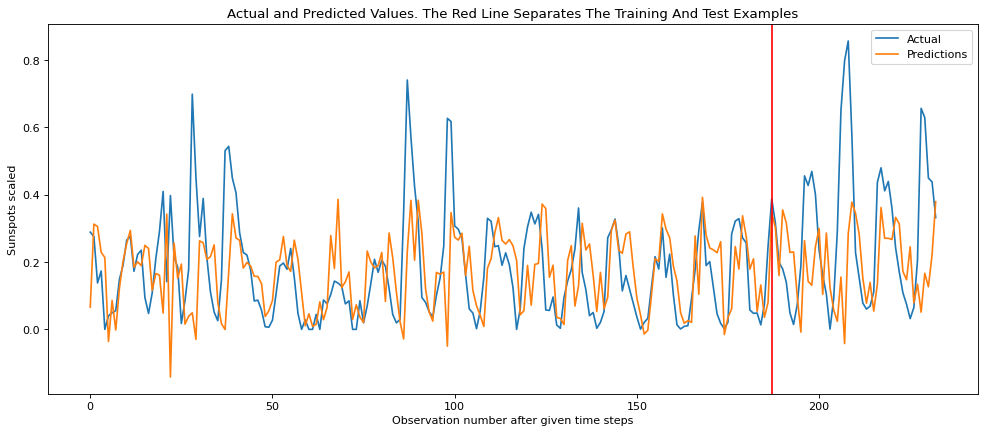

In [18]:
def plot_result(trainY, testY, train_predict, test_predict):
    actual      = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

plot_result(trainY, testY, train_predict, test_predict)